In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.15.0


In [9]:
dataset_path = "brain_tumor_dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 5

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Class indices: {'no': 0, 'yes': 1}


In [11]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_2[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']      

In [12]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_lightweight_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [13]:
history_initial = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/8
13/13 [==============================] - ETA: 0s - loss: 0.6250 - accuracy: 0.6749
Epoch 1: val_accuracy improved from -inf to 0.84000, saving model to best_lightweight_model.h5


D:\MY PROJECT\Brain Tumor Classification\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


13/13 [==============================] - 12s 710ms/step - loss: 0.6250 - accuracy: 0.6749 - val_loss: 0.4187 - val_accuracy: 0.8400 - lr: 0.0010
Epoch 2/8
13/13 [==============================] - ETA: 0s - loss: 0.3165 - accuracy: 0.8522
Epoch 2: val_accuracy did not improve from 0.84000
13/13 [==============================] - 6s 491ms/step - loss: 0.3165 - accuracy: 0.8522 - val_loss: 0.4213 - val_accuracy: 0.8400 - lr: 0.0010
Epoch 3/8
13/13 [==============================] - ETA: 0s - loss: 0.2575 - accuracy: 0.8966
Epoch 3: val_accuracy improved from 0.84000 to 0.90000, saving model to best_lightweight_model.h5
13/13 [==============================] - 6s 429ms/step - loss: 0.2575 - accuracy: 0.8966 - val_loss: 0.2634 - val_accuracy: 0.9000 - lr: 0.0010
Epoch 4/8
13/13 [==============================] - ETA: 0s - loss: 0.2195 - accuracy: 0.9163
Epoch 4: val_accuracy did not improve from 0.90000
13/13 [==============================] - 5s 405ms/step - loss: 0.2195 - accuracy: 0.9163

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
13/13 [==============================] - ETA: 0s - loss: 0.8755 - accuracy: 0.6798
Epoch 1: val_accuracy did not improve from 0.92000
13/13 [==============================] - 11s 521ms/step - loss: 0.8755 - accuracy: 0.6798 - val_loss: 0.3401 - val_accuracy: 0.8600 - lr: 1.0000e-05
Epoch 2/5
13/13 [==============================] - ETA: 0s - loss: 0.6210 - accuracy: 0.7488
Epoch 2: val_accuracy did not improve from 0.92000
13/13 [==============================] - 6s 492ms/step - loss: 0.6210 - accuracy: 0.7488 - val_loss: 0.2780 - val_accuracy: 0.8400 - lr: 1.0000e-05
Epoch 3/5
13/13 [==============================] - ETA: 0s - loss: 0.5324 - accuracy: 0.7931
Epoch 3: val_accuracy did not improve from 0.92000
13/13 [==============================] - 6s 431ms/step - loss: 0.5324 - accuracy: 0.7931 - val_loss: 0.3339 - val_accuracy: 0.8200 - lr: 1.0000e-05
Epoch 4/5
13/13 [==============================] - ETA: 0s - loss: 0.3560 - accuracy: 0.8670
Epoch 4: ReduceLROnPlateau red

In [15]:
train_loss, train_acc = model.evaluate(train_generator, verbose=1)
val_loss, val_acc = model.evaluate(val_generator, verbose=1)

print("Training Accuracy:", round(train_acc * 100, 2), "%")
print("Validation Accuracy:", round(val_acc * 100, 2), "%")

4/4 [==============================] - 2s 433ms/step - loss: 0.3194 - accuracy: 0.8800
Training Accuracy: 93.6 %
Validation Accuracy: 88.0 %


In [16]:
model.save("final_model.h5")
print("Model saved as final_model.h5")

Model saved as final_model.h5


In [17]:
test_model = tf.keras.models.load_model("final_model.h5", compile=False)
print("final_model.h5 loaded successfully")

final_model.h5 loaded successfully


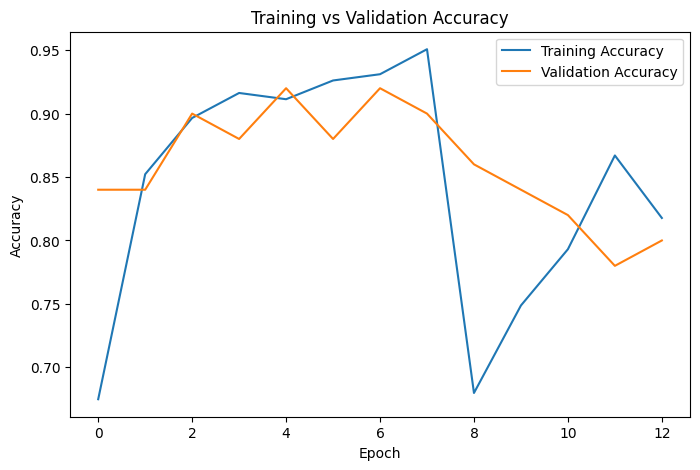

In [18]:
acc = history_initial.history["accuracy"] + history_fine.history["accuracy"]
val_acc_hist = history_initial.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history_initial.history["loss"] + history_fine.history["loss"]
val_loss_hist = history_initial.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc_hist, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [2]:
from PIL import Image

CLASS_NAMES = ["No Tumor", "Tumor"]

def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))
    image = np.array(image, dtype=np.float32) / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def predict_image(image_path):
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        print("To test: replace 'sample.jpg' with your actual image path")
        return
    
    img = preprocess_image(image_path)
    pred = test_model.predict(img)
    confidence = float(pred[0][0])
    
    if confidence >= 0.5:
        label = "Tumor"
        final_conf = confidence * 100
    else:
        label = "No Tumor"
        final_conf = (1 - confidence) * 100
    
    print(f"Prediction  : {label}")
    print(f"Confidence  : {final_conf:.2f}%")

# Replace with your actual image path to test
predict_image("sample.jpg")

Image not found: sample.jpg
To test: replace 'sample.jpg' with your actual image path
